In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN, Input

In [3]:
df = pd.read_csv('googl_data_2020_2025.csv')
print(df)

                          Price    Adj Close        Close         High  \
0                        Ticker        GOOGL        GOOGL        GOOGL   
1                          Date          NaN          NaN          NaN   
2     2020-01-02 00:00:00+00:00  68.18682098  68.43399811  68.43399811   
3     2020-01-03 00:00:00+00:00  67.83010101   68.0759964      68.6875   
4     2020-01-06 00:00:00+00:00  69.63805389  69.89050293  69.91600037   
...                         ...          ...          ...          ...   
1255  2024-12-24 00:00:00+00:00  196.1100006  196.1100006  196.1100006   
1256  2024-12-26 00:00:00+00:00  195.6000061  195.6000061       196.75   
1257  2024-12-27 00:00:00+00:00  192.7599945  192.7599945  195.3200073   
1258  2024-12-30 00:00:00+00:00  191.2400055  191.2400055  192.5500031   
1259  2024-12-31 00:00:00+00:00  189.3000031  189.3000031  191.9600067   

              Low         Open    Volume  
0           GOOGL        GOOGL     GOOGL  
1             NaN        

In [4]:
df.columns


Index(['Price', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [7]:
df['Open'].dtype

dtype('O')

In [8]:
data = pd.to_numeric(df['Open'], errors= 'coerce')

In [9]:
df.isnull().sum()

Price        0
Adj Close    1
Close        1
High         1
Low          1
Open         1
Volume       1
dtype: int64

In [10]:
data = data.dropna()

In [13]:
data.isnull().sum()

0

In [14]:
data = data.values.reshape(-1,1)

In [15]:
#3 feature scaling
scaler = MinMaxScaler(feature_range=(0,1))
data_scaled = scaler.fit_transform(data)

In [16]:
data.dtype

dtype('float64')

In [17]:
#4 Train-test split
train_size = int(len(data_scaled) * 0.8)

train_data = data_scaled[:train_size]
test_data = data_scaled[train_size:]

In [19]:
def create_dataset(dataset):
    X = []
    y = []
    for i in range(60, len(dataset)):
        X.append(dataset[i-60:i, 0])
        y.append(dataset[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_dataset(train_data)

In [20]:
combined_data = np.concatenate((train_data[-60:], test_data), axis=0)
X_test, y_test = create_dataset(combined_data)

X_test = X_test[:len(test_data)]
y_test = y_test[:len(test_data)]

In [21]:
#6 reshape for RNN
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

In [26]:
model = Sequential()

model.add(Input(shape=(60, 1)))
model.add(SimpleRNN(50, return_sequences=True))

model.add(SimpleRNN(50))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)             │ (None, 60, 50)              │           2,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_3 (SimpleRNN)             │ (None, 50)                  │           5,050 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.fit(X_train, y_train, epochs=20, batch_size = 32)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0442
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0027
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0014
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0011
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 8.9605e-04
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 8.0961e-04
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 7.2002e-04
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 6.2097e-04
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 5.6300e-04
Epoch 10/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 5.1140e-04
Epoch 11/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.7649e-04
Epoch 12/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4.6373e-04
Epoch 13/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4.7818e-04
Epoch 14/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.1990e-04
Epoch 15/20
30/30 ━━━━━━━━━━━━━

In [25]:
predicted = model.predict(X_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step


In [27]:
predicted = scaler.inverse_transform(predicted)
real = scaler.inverse_transform(y_test.reshape(-1, 1))

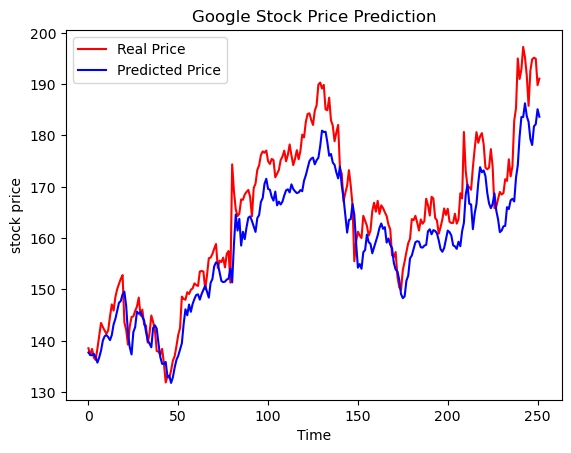

In [29]:
plt.plot(real, color = 'red', label='Real Price')
plt.plot(predicted, color='blue', label='Predicted Price')
plt.title('Google Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('stock price')
plt.legend()
plt.show()